**This notebook demostrates final result**

###**Detection + Tracking Integration**

-  YOLOv7 performs **real-time object detection** on each video frame.  
-  The output (bounding boxes, confidence scores, class IDs) is passed to a tracking module.  
-  Tracking allows the system to **maintain identity of vehicles** across frames using unique IDs.

---

### **SORT Tracking Algorithm**

- SORT (Simple Online and Realtime Tracking) is used to **track detected objects frame-by-frame**.
- Combines **Kalman Filter** (for motion prediction) with **Hungarian Algorithm** (for assignment).
-  Each vehicle is assigned a unique ID and tracked throughout its path.
- Helps with:
  - Detecting when vehicles cross ROI lines  
  - Counting in/out flow



#**Clone YOLOv7 repo and install requirements**

In [ ]:
#Clone YOLOv7 repo and install requirements
!git clone https://github.com/WongKinYiu/yolov7.git
%cd /content/yolov7



Cloning into 'yolov7'...
remote: Enumerating objects: 1197, done.
remote: Total 1197 (delta 0), reused 0 (delta 0), pack-reused 1197 (from 1)
Receiving objects: 100% (1197/1197), 74.29 MiB | 28.65 MiB/s, done.
Resolving deltas: 100% (513/513), done.
/content/yolov7


In [ ]:
!ls


best.pt  detect.py   inference	 paper		   scripts	 train.py
cfg	 export.py   LICENSE.md  __pycache__	   test.py	 utils
data	 figure      models	 README.md	   tools	 yolov7
deploy	 hubconf.py  output	 requirements.txt  train_aux.py  yolov7.pt


In [ ]:
#Downloading pretrained weights
!wget https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt -P /content/yolov7/

--2025-08-19 18:04:25--  https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/511187726/b0243edf-9fb0-4337-95e1-42555f1b37cf?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-08-19T19%3A02%3A05Z&rscd=attachment%3B+filename%3Dyolov7.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-08-19T18%3A02%3A05Z&ske=2025-08-19T19%3A02%3A05Z&sks=b&skv=2018-11-09&sig=iF37UvLnXNZpYFiLo%2B%2Fn5w%2B295sWVzTPTX7f7%2B9Hk34%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc1NTYyNjk2NSwibmJmIjoxNzU1NjI2NjY1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcm

In [ ]:
!pip install filterpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=46ab433cdeb2a7b41eee6965624dede5e8a61f4733011ce97b32f09c820eff43
  Stored in directory: /root/.cache/pip/wheels/12/dc/3c/e12983eac132d00f82a20c6cbe7b42ce6e96190ef8fa2d15e1
Successfully built filterpy


##**Sort Tracking**

##**sort.py**

In [ ]:
#sort.py
sort='''
import numpy as np
from filterpy.kalman import KalmanFilter

def iou(bb_test, bb_gt):
    """
    Computes IOU between two bounding boxes [x1,y1,x2,y2]
    """
    xx1 = np.maximum(bb_test[0], bb_gt[0])
    yy1 = np.maximum(bb_test[1], bb_gt[1])
    xx2 = np.minimum(bb_test[2], bb_gt[2])
    yy2 = np.minimum(bb_test[3], bb_gt[3])
    w = np.maximum(0., xx2 - xx1)
    h = np.maximum(0., yy2 - yy1)
    inter = w * h
    area1 = (bb_test[2] - bb_test[0]) * (bb_test[3] - bb_test[1])
    area2 = (bb_gt[2] - bb_gt[0]) * (bb_gt[3] - bb_gt[1])
    o = inter / (area1 + area2 - inter + 1e-6)  # Added epsilon for stability
    return o

def convert_bbox_to_z(bbox):
    """
    Converts [x1,y1,x2,y2] to [x, y, s, r]
    """
    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]
    x = bbox[0] + w/2.
    y = bbox[1] + h/2.
    s = w * h
    r = w / float(h + 1e-6)  # Avoid div by zero
    return np.array([x, y, s, r]).reshape((4,1))
def convert_bbox_to_z(bbox):
    """
    Convert bbox from [x1, y1, x2, y2] to [x_center, y_center, scale, ratio]
    """
    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]
    x = bbox[0] + w / 2.
    y = bbox[1] + h / 2.
    s = w * h  # scale is area
    r = w / float(h + 1e-6)  # add epsilon to avoid division by zero
    return np.array([x, y, s, r]).reshape((4, 1))


def convert_x_to_bbox(x, score=None):
    """
    Convert state vector [x, y, s, r] to bounding box [x1, y1, x2, y2],
    optionally append score
    """
    w = np.sqrt(x[2] * x[3])
    h = x[2] / (w + 1e-6)
    x1 = x[0] - w / 2.
    y1 = x[1] - h / 2.
    x2 = x[0] + w / 2.
    y2 = x[1] + h / 2.
    if score is None:
        return np.array([x1, y1, x2, y2]).reshape((1, 4))
    else:
        return np.array([x1, y1, x2, y2, score]).reshape((1, 5))


class KalmanBoxTracker:
    count = 0  # Class variable to assign unique IDs

    def __init__(self, bbox):
        # Initialize Kalman filter
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([[1,0,0,0,1,0,0],
                              [0,1,0,0,0,1,0],
                              [0,0,1,0,0,0,1],
                              [0,0,0,1,0,0,0],
                              [0,0,0,0,1,0,0],
                              [0,0,0,0,0,1,0],
                              [0,0,0,0,0,0,1]])
        self.kf.H = np.array([[1,0,0,0,0,0,0],
                              [0,1,0,0,0,0,0],
                              [0,0,1,0,0,0,0],
                              [0,0,0,1,0,0,0]])
        self.kf.R[2:,2:] *= 10.
        self.kf.P[4:,4:] *= 1000.
        self.kf.P *= 10.
        self.kf.Q[-1,-1] *= 0.01
        self.kf.Q[4:,4:] *= 0.01

        self.kf.x[:4] = convert_bbox_to_z(bbox)

        self.time_since_update = 0
        self.id = KalmanBoxTracker.count  # Assign unique ID
        KalmanBoxTracker.count += 1       # Increment for next tracker
        self.history = []
        self.hits = 0
        self.hit_streak = 0
        self.age = 0


    def update(self, bbox):
        self.time_since_update = 0
        self.history.clear()
        self.hits += 1
        self.hit_streak += 1
        self.kf.update(convert_bbox_to_z(bbox))

    def predict(self):
        if (self.kf.x[6] + self.kf.x[2]) <= 0:
            self.kf.x[6] *= 0.0
        self.kf.predict()
        self.age += 1
        if self.time_since_update > 0:
            self.hit_streak = 0
        self.time_since_update += 1
        bbox = convert_x_to_bbox(self.kf.x)
        self.history.append(bbox)
        return bbox

    def get_state(self):
        return convert_x_to_bbox(self.kf.x)

class Sort:
    def __init__(self, max_age=30, min_hits=3, iou_threshold=0.3):
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.trackers = []
        self.frame_count = 0

    def update(self, dets=np.empty((0,5))):
        self.frame_count += 1

        trks = np.zeros((len(self.trackers), 5))
        to_del = []

        for t, trk in enumerate(self.trackers):
            pos = trk.predict()[0]
            trks[t, :4] = pos
            trks[t, 4] = 0  # Dummy score
            if np.any(np.isnan(pos)):
                to_del.append(t)

        for t in reversed(to_del):
            self.trackers.pop(t)
            trks = np.delete(trks, t, axis=0)

        matched, unmatched_dets, unmatched_trks = associate_detections_to_trackers(dets, trks, self.iou_threshold)

        # Update matched trackers
        for t, trk_idx in enumerate(matched[:,1]):
            det_idx = matched[t,0]
            self.trackers[trk_idx].update(dets[det_idx,:4])

        # Create new trackers for unmatched detections
        for idx in unmatched_dets:
            self.trackers.append(KalmanBoxTracker(dets[idx,:4]))

        ret = []
        i = len(self.trackers)
        for trk in reversed(self.trackers):
            d = trk.get_state()[0]
            if (trk.time_since_update < 1) and (trk.hit_streak >= self.min_hits or self.frame_count <= self.min_hits):
                ret.append(np.concatenate((d, [trk.id + 1])).reshape(1,-1))  # ID starts at 1
            i -= 1
            if trk.time_since_update > self.max_age:
                self.trackers.pop(i)

        if len(ret) > 0:
            return np.concatenate(ret)
        return np.empty((0,5))

def associate_detections_to_trackers(detections, trackers, iou_threshold=0.3):
    if len(trackers) == 0:
        return np.empty((0,2),dtype=int), np.arange(len(detections)), np.empty((0,), dtype=int)

    iou_matrix = np.zeros((len(detections), len(trackers)), dtype=np.float32)

    for d, det in enumerate(detections):
        for t, trk in enumerate(trackers):
            iou_matrix[d,t] = iou(det[:4], trk[:4])

    from scipy.optimize import linear_sum_assignment
    matched_indices = linear_sum_assignment(-iou_matrix)
    matched_indices = np.array(matched_indices).T

    unmatched_detections = [d for d in range(len(detections)) if d not in matched_indices[:,0]]
    unmatched_trackers = [t for t in range(len(trackers)) if t not in matched_indices[:,1]]

    matches = []
    for m in matched_indices:
        if iou_matrix[m[0], m[1]] < iou_threshold:
            unmatched_detections.append(m[0])
            unmatched_trackers.append(m[1])
        else:
            matches.append(m.reshape(1,2))

    if len(matches) == 0:
        matches = np.empty((0,2),dtype=int)
    else:
        matches = np.concatenate(matches, axis=0)

    return matches, np.array(unmatched_detections), np.array(unmatched_trackers)

    '''
with open("sort.py", "w") as f:
    f.write(sort)

##**The pretrained model named best.pt was created in a previous notebook. Please upload that model to the /content/yolov7 directory.**

##**detect_track.py**

In [ ]:
detect_track_code = """
import cv2
import torch
import numpy as np
import os
import time
from sort import Sort
from models.experimental import attempt_load
from utils.general import non_max_suppression, scale_coords
from utils.torch_utils import select_device
from IPython.display import display, clear_output
import PIL.Image

CLASSES = [
    'Indian Auto',
    'Indian Truck',
    'Bus',
    'Truck',
    'Tempo Traveller',
    'Tractor',
    'Car',
    'Two Wheeler'
]

ROI_LINE_Y = 300

def draw_roi(frame):
    h, w = frame.shape[:2]
    cv2.line(frame, (0, ROI_LINE_Y), (w, ROI_LINE_Y), (255, 0, 0), 2)

def crossed_line(y_old, y_new, line_y):
    return (y_old < line_y and y_new >= line_y) or (y_old > line_y and y_new <= line_y)

def main(source=0, weights='/content/yolov7/best.pt', save_path='output/tracked_output.mp4'):
    device = select_device('')
    model = attempt_load(weights, map_location=device)
    model.eval()

    tracker = Sort(max_age=30, min_hits=3, iou_threshold=0.3)
    cap = cv2.VideoCapture(source)

    if not cap.isOpened():
        print(f"Error opening video source {source}")
        return

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1.0 or np.isnan(fps):
      fps = 30  # safe fallback


    save_dir = os.path.dirname(save_path)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(save_path, fourcc, fps, (width, height))

    track_hist = {}
    in_count, out_count = 0, 0
    try:
      while True:
        ret, frame = cap.read()
        if not ret:
            break

        img = cv2.resize(frame, (640, 640))
        img = torch.from_numpy(img).to(device).float() / 255.0
        img = img.permute(2, 0, 1).unsqueeze(0)

        with torch.no_grad():
            pred = model(img)[0]
        pred = non_max_suppression(pred, 0.25, 0.45)[0]

        detections, class_ids = [], []

        if pred is not None and len(pred):
            pred[:, :4] = scale_coords(img.shape[2:], pred[:, :4], frame.shape).round()
            for *xyxy, conf, cls in pred:
                x1, y1, x2, y2 = map(int, xyxy)
                detections.append([x1, y1, x2, y2, float(conf)])
                class_ids.append(int(cls))

        detections_np = np.array(detections)
        if len(detections_np):
            outputs = tracker.update(detections_np)
        else:
            outputs = np.empty((0, 5))

        draw_roi(frame)

        for det in outputs:
            if len(det) < 5:
                continue
            x1, y1, x2, y2, track_id = det[:5].astype(int)
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2

            cls = -1
            for j, (dx1, dy1, dx2, dy2, conf) in enumerate(detections):
                if abs(x1 - dx1) < 10 and abs(y1 - dy1) < 10:
                    cls = class_ids[j]
                    break

            label = f"{CLASSES[cls]} ID {track_id}" if 0 <= cls < len(CLASSES) else f"ID {track_id}"

            if track_id not in track_hist:
                track_hist[track_id] = []
            track_hist[track_id].append((cx, cy))

            if len(track_hist[track_id]) >= 2:
                y_old = track_hist[track_id][-2][1]
                y_new = track_hist[track_id][-1][1]
                if crossed_line(y_old, y_new, ROI_LINE_Y):
                    if y_new > ROI_LINE_Y:
                        in_count += 1
                    else:
                        out_count += 1
                    track_hist[track_id] = []

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)

            for k in range(1, len(track_hist[track_id])):
                cv2.line(frame, track_hist[track_id][k - 1], track_hist[track_id][k], (0, 0, 255), 2)

        cv2.putText(frame, f"IN: {in_count}", (10, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)
        cv2.putText(frame, f"OUT: {out_count}", (10, 100),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

        display(PIL.Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        clear_output(wait=True)
        time.sleep(0.03)

        out.write(frame)
    finally:
      cap.release()
      out.release()

if __name__ == "__main__":
    main('/content/yolov7/test1.mp4', '/content/yolov7/best.pt', 'output/tracked_output.mp4')

"""

with open("detect_track.py", "w") as f:
    f.write(detect_track_code)


In [ ]:
import sys
import os

# Change to YOLOv7 directory
%cd /content/yolov7

# Add YOLOv7 to Python path
if '/content/yolov7' not in sys.path:
    sys.path.append('/content/yolov7')


/content/yolov7


In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.1.1 torchvision==0.16.1 torchaudio==2.1.1 --index-url https://download.pytorch.org/whl/cu121


Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 GB 651.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 94.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 MB 8.3 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.2.0
    Uninstalling triton-3.2.0:
      Successfully uninstalled triton-3.2.0


**Upload a Input video**

In [ ]:
#uploading a input video
from google.colab import files
import os

uploaded = files.upload()
for filename in uploaded.keys():
    input_video_path = filename
    print(f"Uploaded file: {filename}")

Saving test1.mp4 to test1.mp4
Uploaded file: test1.mp4


In [ ]:
!pip install "numpy<2.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 86.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


#**RESULT:**

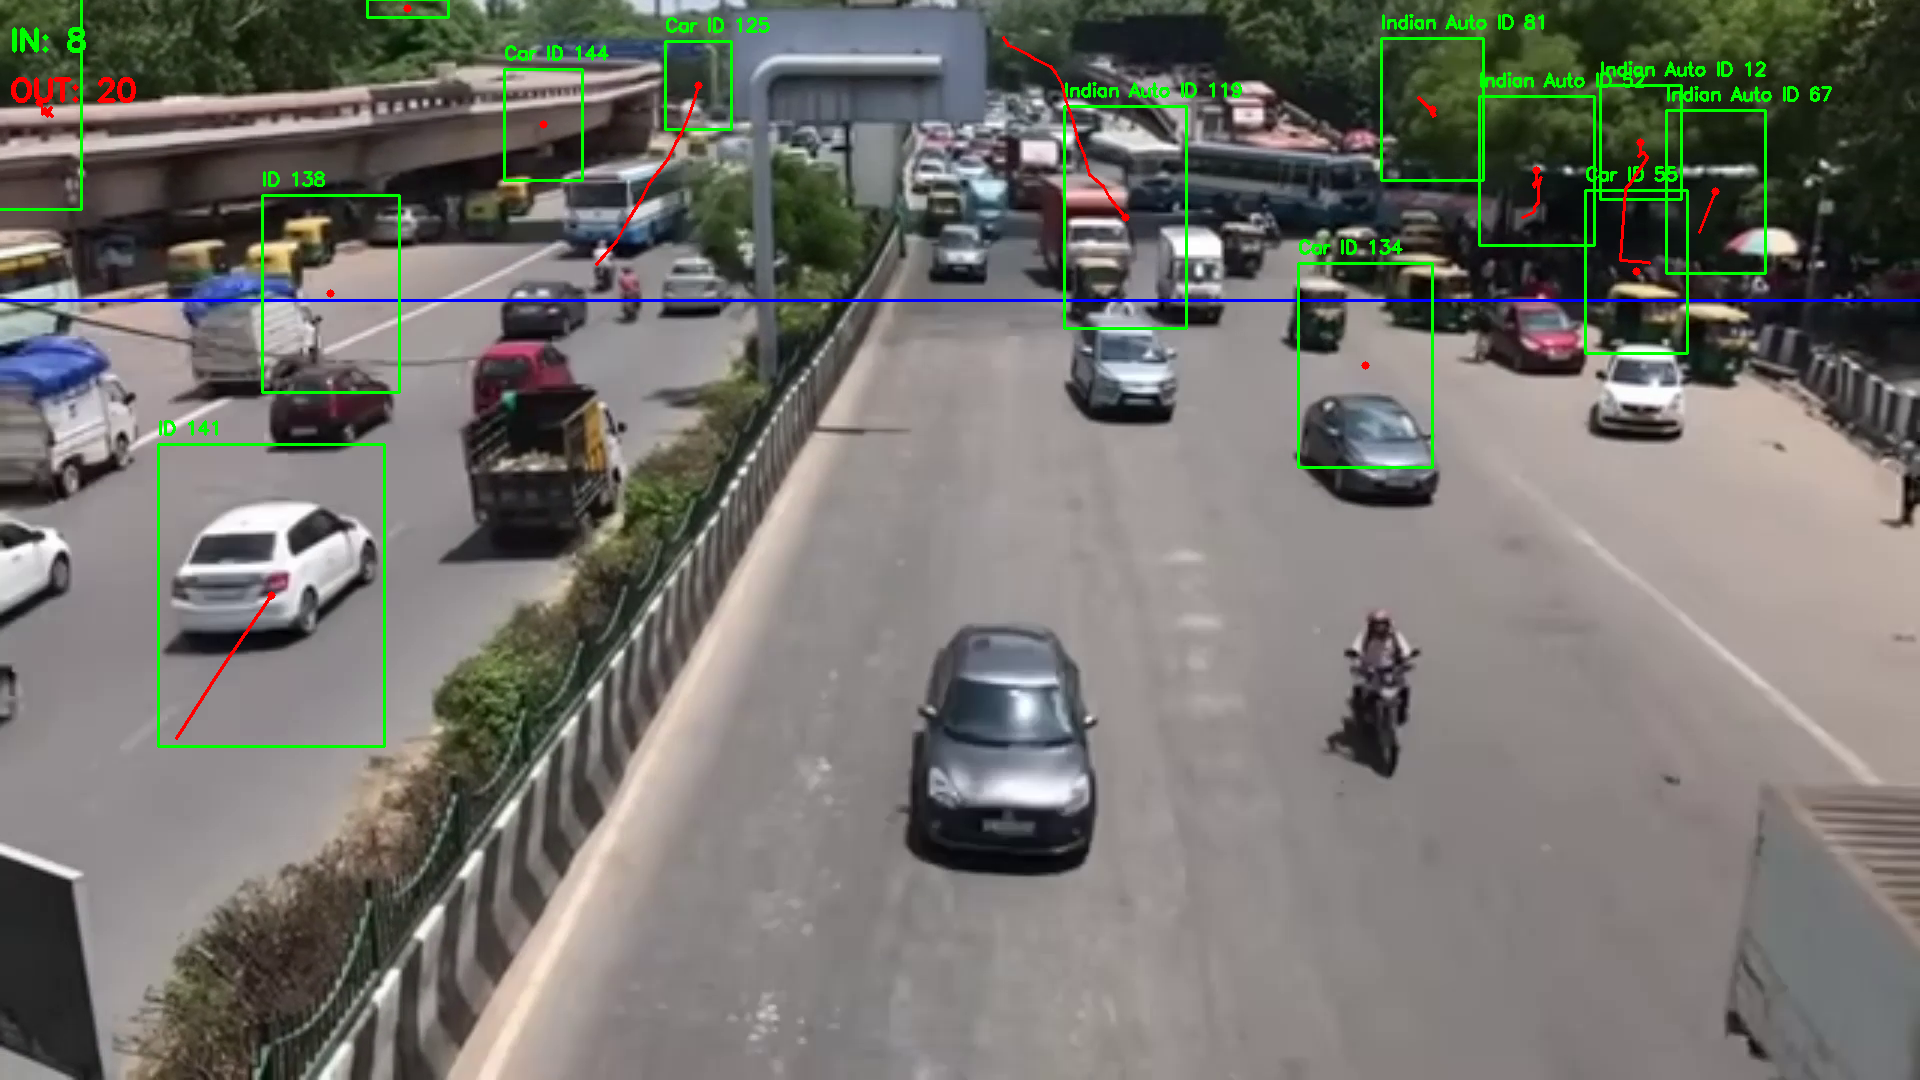

In [ ]:
import numpy as np
from detect_track import main

# Run on input video file with  weights and save path
main(source='/content/yolov7/test1.mp4', weights='/content/yolov7/best.pt', save_path='/content/yolov7/output/tracked_output.mp4')




##**RESULT:VIDEO**

In [ ]:
from IPython.display import HTML, display
from base64 import b64encode
import os

# Input and output paths
save_path = '/content/yolov7/output/tracked_output.mp4'
compressed_path = "/content/result_compressed.mp4"

# Compress the video using ffmpeg
os.system(f"ffmpeg -y -i {save_path} -vcodec libx264 -crf 28 {compressed_path}")

# Read and encode video
mp4 = open(compressed_path, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

# Display HTML video player
display(HTML(f"""
<video width="640" height="480" controls>
    <source src="{data_url}" type="video/mp4">
    Your browser does not support the video tag.
</video>
"""))


##**STREAMLIT APPLICATION:**

In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.2 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import tempfile
import os
import subprocess
import logging
logging.getLogger('streamlit.runtime.scriptrunner').setLevel(logging.ERROR)


st.set_page_config(page_title="Vehicle Detection & Tracking", layout="centered")
st.title("🚗 Vehicle Detection, Tracking & Counting")

st.info("Upload a video to run detection and tracking. This version uses a pre-trained YOLOv7 model and SORT tracker.")

uploaded_file = st.file_uploader(" Upload a video file", type=["mp4", "avi", "mov"])
run_button = st.button(" Run Detection & Tracking")

if uploaded_file and run_button:
    with tempfile.NamedTemporaryFile(delete=False, suffix=".mp4") as temp_video:
        temp_video.write(uploaded_file.read())
        input_path = temp_video.name

    # Define output path
    output_path = os.path.join(tempfile.gettempdir(), "output_tracked.mp4")

    # Path to YOLOv7 weights (make sure this file exists)
    weights_path = "/content/yolov7/best.pt"

    # Call the detect_track.py script
    st.info("Running detection and tracking...")
    result = subprocess.run(
        ["python3", "detect_track.py", input_path, weights_path, output_path],
        capture_output=True,
        text=True
    )

    if result.returncode == 0 and os.path.exists(output_path):
        st.success("Detection complete! Here's the output:")
        st.video(output_path)
    else:
        st.error("Detection failed. See error log below:")
        st.text(result.stderr)


Writing app.py


In [ ]:
!streamlit run app.py





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.85.208.246:8501

  Stopping...
  Stopping...


**The Streamlit app gets interrupted on the results page, so run the code in VS Code to avoid this issue**

In [ ]:
# Zip the folder
!zip -r yolov7.zip /content/yolov7

# Download the zip file
from google.colab import files
files.download('yolov7.zip')


  adding: content/yolov7/ (stored 0%)
  adding: content/yolov7/yolov7.pt (deflated 8%)
  adding: content/yolov7/__pycache__/ (stored 0%)
  adding: content/yolov7/__pycache__/detect_track.cpython-311.pyc (deflated 46%)
  adding: content/yolov7/__pycache__/sort.cpython-311.pyc (deflated 58%)
  adding: content/yolov7/sort.py (deflated 71%)
  adding: content/yolov7/tools/ (stored 0%)
  adding: content/yolov7/tools/instance.ipynb (deflated 25%)
  adding: content/yolov7/tools/compare_YOLOv7e6_vs_YOLOv5x6_half.ipynb (deflated 41%)
  adding: content/yolov7/tools/keypoint.ipynb (deflated 25%)
  adding: content/yolov7/tools/YOLOv7onnx.ipynb (deflated 25%)
  adding: content/yolov7/tools/visualization.ipynb (deflated 25%)
  adding: content/yolov7/tools/YOLOv7-Dynamic-Batch-TENSORRT.ipynb (deflated 28%)
  adding: content/yolov7/tools/compare_YOLOv7e6_vs_YOLOv5x6.ipynb (deflated 41%)
  adding: content/yolov7/tools/reparameterization.ipynb (deflated 93%)
  adding: content/yolov7/tools/compare_YOLOv7_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>